# 05 - Auditoria: modelo subrogado con reglas

**Objetivo:** ajustar un modelo subrogado interpretable (arbol de decision) que aproxime cada uno de
los dos modelos de caja negra, extraer reglas legibles y medir su fidelidad.

**Por que hace falta.** El modelo que decide es XGBoost: un ensemble de cientos de arboles cuya
salida ningun humano puede justificar leyendo sus parametros. El enunciado, sin embargo, exige poder
explicar la decision ("si un cliente pide explicaciones sobre por que se le deniega un credito, que
informacion le damos?"). El subrogado es la respuesta clasica: entrenamos un modelo *interpretable*
-un arbol poco profundo- cuyo objetivo NO es predecir el impago, sino **imitar a la caja negra**. Si
el arbol reproduce sus decisiones con fidelidad alta, sus reglas if/then son un retrato legible de
la logica que XGBoost aplica de hecho.

**La distincion critica (fidelidad != accuracy).** El subrogado se entrena contra
`modelo.predict(X)`, NUNCA contra `SeriousDlqin2yrs`. Y se evalua igual: la metrica es la
**fidelidad** (coincidencia con la caja negra), no la accuracy (acierto sobre la verdad). La razon es
conceptual, no tecnica: no estamos construyendo un modelo alternativo -ya tenemos uno-, sino un
EXPLICADOR. Un subrogado con fidelidad perfecta a un modelo mediocre seria un explicador perfecto de
un modelo mediocre, y eso es exactamente lo que queremos: describir lo que el modelo hace, aciertos y
errores incluidos. Ver `docs/teoria/subrogados.md`, seccion 3.4.

**Entregables que produce este notebook:**
- `results/tables/reglas_subrogado_coste1.md` y `reglas_subrogado_coste10.md`
- `results/figures/arbol_subrogado_coste1.png` y `arbol_subrogado_coste10.png`
- `results/tables/sub_05_fidelidad.csv` (tabla de fidelidad por escenario)
- `results/figures/sub_05_fidelidad_vs_profundidad.png` (curva del trade-off)

## Conectores

**Recibe:**
- `results/models/modelo_coste1.joblib` (de `03_modelo_coste1.ipynb`): bundle con el estimador
  XGBoost refiteado en train completo y su umbral simetrico (~0.4934).
- `results/models/modelo_coste10.joblib` (de `04_modelo_coste10.ipynb`): MISMO estimador XGBoost,
  umbral asimetrico (~0.0906). Recordatorio de D-0.2: un solo scoring, dos umbrales.
- `data/processed/test.parquet` (de `02_preprocesado.ipynb`): 21000 filas, 12 features. Es el
  conjunto sobre el que auditamos.

**Entrega** a `99_ENTREGA.ipynb` (seccion de auditoria):
- Reglas legibles por escenario, figuras de los arboles y la tabla de fidelidad.

**Por que auditamos sobre TEST y no sobre train.** El subrogado debe imitar a la caja negra en el
regimen donde esta opera, no donde memorizo. Sobre train, XGBoost esta sobreajustado y sus
decisiones son mas "limpias" de lo que seran en produccion; un subrogado ajustado ahi daria una
fidelidad optimista y unas reglas que no describen el comportamiento real. Test (21000 filas no
vistas) es la muestra honesta. No hay fuga posible: no estamos eligiendo hiperparametros del modelo
principal, solo describiendo un modelo YA CERRADO.

## Decisiones que afectan a este notebook

- **D-0.3** (familia de modelo): **CERRADA** a favor de **XGBoost**, un modelo de caja negra. Esto
  hace que el subrogado mantenga toda su relevancia: si el modelo principal fuera una regresion
  logistica, seria directamente interpretable y aproximarlo con reglas seria redundante. No es el
  caso.
- **D-0.2** (un scoring + dos umbrales): **CERRADA**. Los dos escenarios comparten el MISMO score de
  caja negra, pero su DECISION (`y_predicha`) difiere porque el umbral cambia (0.4934 vs 0.0906).
  Como el subrogado imita DECISIONES, no probabilidades, cada escenario necesita su propio arbol
  (secciones 2 y 3). Asumir que las reglas de uno valen para el otro seria un error.

- **D-5.1 (se cierra aqui): complejidad del arbol y metrica de fidelidad.**

  *Complejidad.* Se limita por **`max_depth`**, y no se fija a dedo: se barren las profundidades 2-6
  y se reporta la **curva fidelidad-vs-profundidad** (seccion 2). Asi el trade-off
  interpretabilidad<->fidelidad no se afirma, se DEMUESTRA, y la profundidad elegida queda
  justificada por el punto donde la curva se aplana (ganancia marginal de fidelidad que ya no
  compensa la perdida de legibilidad). La alternativa (`max_leaf_nodes`, patron del material de
  partida) es igual de valida; se prefiere `max_depth` porque produce reglas de longitud acotada
  ("si se cumplen estas <=D condiciones -> denegar"), que es justo el formato que un cliente o un
  regulador puede leer.

  *Metrica.* Se reportan **tres**, porque una sola engana:
  1. **Fidelidad global**: % de decisiones coincidentes con la caja negra. Es la cifra titular, pero
     es TRAMPOSA bajo desbalanceo (ver abajo).
  2. **Fidelidad por clase**: coincidencia dentro de los "concedidos" y dentro de los "denegados"
     por la caja negra, por separado.
  3. **F1 sobre la clase "denegar"**, tratando la salida de XGBoost como etiqueta.

  *Por que tres y no una.* En el escenario simetrico XGBoost solo deniega al **2.4%**. Un subrogado
  degenerado que dijera "conceder siempre" alcanzaria **~97.6% de fidelidad global** sin haber
  aprendido NADA y sin producir una sola regla util. Reportar solo la fidelidad global permitiria
  vender ese 97% como un exito; la fidelidad por clase y el F1 lo desenmascaran de inmediato. Este
  es el riesgo real del escenario simetrico y lo declaramos por adelantado.

## 1. Carga de los modelos entrenados y del conjunto de test

Cargamos los dos bundles de `03` y `04` y el `test.parquet`. De cada bundle extraemos el estimador
XGBoost y su umbral, y verificamos explicitamente la tesis de **D-0.2**: que el estimador es el mismo
objeto en ambos escenarios y que lo unico que cambia es el punto de corte.

Generamos aqui las dos **etiquetas objetivo** del subrogado, que son el corazon del notebook:
`y_bb_coste1` y `y_bb_coste10` = las decisiones de la caja negra en test bajo cada umbral. Insisto:
estas, y no `SeriousDlqin2yrs`, son lo que los arboles van a aprender a imitar.

In [1]:
# === Configuracion - notebook 05 (auditoria: subrogado) ===
# NOTA: este notebook NO importa src.modeling (que arrastra TensorFlow/Keras para los MLP).
# El subrogado solo necesita sklearn + xgboost + pandas. Cargamos los bundles con joblib
# directo: los .joblib de 03/04 contienen los estimadores YA entrenados, no hay que reentrenar.
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import joblib

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import f1_score, precision_score, recall_score

# cwd = raiz del repo -> rutas SIN "../" (mismo contrato que 03/04).
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import src.cost_utils as cu          # modulo PURO (numpy): no arrastra TF

RANDOM_STATE = 42
TARGET = cu.TARGET
np.random.seed(RANDOM_STATE)

# --- Paleta heredada de 01-04 (coherencia visual del proyecto) ---
COLOR_TARGET = {0: "#2a78d6", 1: "#e34948"}
COLOR_INK_PRIMARY = "#0b0b0b"
COLOR_INK_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BASELINE = "#c3c2b7"
COLOR_GANADOR = "#1c5cab"
COLOR_ESC1 = "#8aa9cf"                # esc1 (simetrico)  - azul suave
COLOR_ESC2 = "#b5462f"                # esc2 (asimetrico) - teja
CMAP_SEQUENTIAL = "Blues"

plt.rcParams.update({
    "figure.figsize": (8, 5), "figure.dpi": 130, "savefig.dpi": 130,
    "axes.edgecolor": COLOR_BASELINE, "axes.labelcolor": COLOR_INK_PRIMARY,
    "text.color": COLOR_INK_PRIMARY, "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED, "grid.color": COLOR_GRID, "axes.grid": True,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
})
sns.set_style("white")


def guardar_figura(fig, nombre):
    """Guarda en results/figures/{nombre}.png (prefijo sub_05_ o arbol_subrogado_)."""
    os.makedirs("results/figures", exist_ok=True)
    fig.tight_layout()
    fig.savefig(f"results/figures/{nombre}.png", dpi=130, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre, index=False):
    """Guarda en results/tables/{nombre}.csv (prefijo sub_05_)."""
    os.makedirs("results/tables", exist_ok=True)
    ruta = f"results/tables/{nombre}.csv"
    df.to_csv(ruta, index=index)
    return ruta


# --- Carga de los dos bundles y del test ---
bundle1 = joblib.load("results/models/modelo_coste1.joblib")
bundle10 = joblib.load("results/models/modelo_coste10.joblib")
test = pd.read_parquet("data/processed/test.parquet")

FEATURES = list(bundle1["features"])          # 12 columnas, orden canonico del contrato
X_test = test[FEATURES].copy()
y_real = test[TARGET].to_numpy(dtype=int)     # SOLO para contexto; el subrogado NO lo usa

# El estimador supervisado (xgboost) vive en bundle["supervisado"]["modelo"] en 03; en 04 el
# bundle guarda el mismo estimador en bundle["modelo"] (reutilizado, con otro umbral).
modelo_bb = bundle1["supervisado"]["modelo"]  # la CAJA NEGRA (un solo scoring, D-0.2)
umbral_c1 = float(bundle1["umbral"])          # ~0.4934 (simetrico)
umbral_c10 = float(bundle10["umbral"])        # ~0.0906 (asimetrico)

# --- Verificacion explicita de D-0.2: UN scoring, DOS umbrales ---
proba_bb = np.asarray(modelo_bb.predict_proba(X_test))[:, 1].astype("float64")
proba_bb_04 = np.asarray(bundle10["modelo"].predict_proba(X_test))[:, 1].astype("float64")
dif_scoring = float(np.max(np.abs(proba_bb - proba_bb_04)))
assert dif_scoring < 1e-9, f"D-0.2 ROTA: los scorings de 03 y 04 difieren (max|dif|={dif_scoring})"
print(f"[D-0.2] mismo scoring en 03 y 04: max|dif| = {dif_scoring:.2e}  -> confirmado")

# --- LAS ETIQUETAS OBJETIVO DEL SUBROGADO (el corazon del notebook) ---
# NO es y_real. Es lo que la CAJA NEGRA decide. El subrogado imita esto.
y_bb_c1 = cu.aplicar_umbral(proba_bb, umbral_c1)     # decisiones esc1 (simetrico)
y_bb_c10 = cu.aplicar_umbral(proba_bb, umbral_c10)   # decisiones esc2 (asimetrico)

deny_c1 = float(y_bb_c1.mean())
deny_c10 = float(y_bb_c10.mean())

print()
print(f"test: {X_test.shape}  features: {len(FEATURES)}")
print(f"umbral coste1  = {umbral_c1:.6f}  ->  la caja negra deniega al {deny_c1 * 100:.2f}% "
      f"({int(y_bb_c1.sum())} de {len(y_bb_c1)})")
print(f"umbral coste10 = {umbral_c10:.6f}  ->  la caja negra deniega al {deny_c10 * 100:.2f}% "
      f"({int(y_bb_c10.sum())} de {len(y_bb_c10)})")
print()
print(f"[AVISO] prevalencia de 'denegar' en esc1 = {deny_c1 * 100:.2f}%. Un subrogado degenerado")
print(f"        que dijera 'conceder siempre' tendria ya {(1 - deny_c1) * 100:.2f}% de fidelidad")
print(f"        GLOBAL sin aprender nada. Por eso la seccion 5 mide tambien fidelidad por clase.")
print()
print(f"contexto (NO se usa para entrenar): impago real en test = {y_real.mean() * 100:.2f}%")

[D-0.2] mismo scoring en 03 y 04: max|dif| = 0.00e+00  -> confirmado

test: (21000, 12)  features: 12
umbral coste1  = 0.493394  ->  la caja negra deniega al 2.38% (499 de 21000)
umbral coste10 = 0.090609  ->  la caja negra deniega al 18.70% (3926 de 21000)

[AVISO] prevalencia de 'denegar' en esc1 = 2.38%. Un subrogado degenerado
        que dijera 'conceder siempre' tendria ya 97.62% de fidelidad
        GLOBAL sin aprender nada. Por eso la seccion 5 mide tambien fidelidad por clase.

contexto (NO se usa para entrenar): impago real en test = 6.69%


**Hallazgo 1.1 (integridad del artefacto heredado):** Antes de auditar un modelo hay que verificar
que el modelo que se carga ES el modelo que se entreno. Al abrir `modelo_coste1.joblib` con una
version de XGBoost distinta a la del entrenamiento (2.1.4 frente a la 3.2.0 fijada en
`requirements.txt`), el `base_score` aprendido durante el ajuste no se restaura y se reconstruye con
el valor por defecto (0.5). El efecto es silencioso y traicionero: el RANKING se conserva intacto
(AUC 0.870, identico), pero la ESCALA de las probabilidades se infla ~x5 (media 0.33 frente a la
prevalencia real 0.067). Aplicando los umbrales de `03`/`04` sobre ese scoring inflado, el modelo
denegaria al **25%** y al **85%** de los solicitantes en vez de al 2.4% y al 18.7%, y el coste en
test se disparaba de 0.063 a 0.214. La prueba de que se trataba de serializacion y no del modelo:
el `oof_proba` guardado en el MISMO bundle si estaba bien calibrado (media 0.0667 ~ prevalencia
0.0668).

Fijada la version de XGBoost a la del `requirements.txt` (3.2.0), el bundle carga correctamente: la
caja negra deniega al **2.38%** en el escenario simetrico y al **18.70%** en el asimetrico, cifras
que reproducen exactamente las publicadas en `03` y `04`. El modelo auditado en este notebook es,
por tanto, el MISMO que genero los entregables `cs_produccion1.csv` y `cs_produccion2.csv`.
**Leccion de reproducibilidad:** un `joblib.dump` del wrapper de XGBoost NO es portable entre
versiones. La alternativa robusta es serializar el booster en su formato JSON nativo
(`booster.save_model()`), estable entre versiones, y fijar las versiones en `requirements.txt` (ya
hecho).

## 2. Ajuste del arbol subrogado para el escenario coste1 (simetrico)

Entrenamos un `DecisionTreeClassifier` cuyo objetivo es `y_bb_c1`: las **decisiones de la caja
negra** en test bajo el umbral simetrico (0.4934). Insistimos en lo que ya se dijo: el objetivo NO
es `SeriousDlqin2yrs`. El arbol no aprende a predecir impagos, aprende a **imitar a XGBoost**.

**La profundidad no se fija a dedo.** Barremos `max_depth` en {2, 3, 4, 5, 6, 8, 10, None} y
reportamos la curva de fidelidad. Asi el compromiso interpretabilidad<->fidelidad queda DEMOSTRADO,
y la profundidad final se elige por donde la curva se aplana: el punto a partir del cual anadir
niveles ya no compra fidelidad, solo cuesta legibilidad.

**Cuatro metricas, no una (cierre de D-5.1).** La caja negra solo deniega al **2.38%** en este
escenario, asi que la fidelidad global esta contaminada por el desbalanceo: un arbol degenerado que
respondiera "conceder" a todo el mundo alcanzaria **97.62% de fidelidad global** sin haber aprendido
nada y sin producir una sola regla util. Para desenmascararlo reportamos:

| metrica | que mide | por que |
|---|---|---|
| `fidelidad_global` | % de decisiones coincidentes | cifra titular, pero TRAMPOSA aqui |
| `fid_conceder` | coincidencia entre los que la caja negra CONCEDE | sera ~99% incluso en un arbol malo |
| **`fid_denegar`** | **coincidencia entre los que la caja negra DENIEGA** | **aqui se ve si el arbol aprendio algo** |
| `f1_denegar` | F1 tratando "denegar" como clase positiva | resumen honesto de las dos anteriores |

`fid_denegar` es el detector de fraude: un subrogado degenerado la tendria a **0%**, por muy bonita
que fuera su fidelidad global. Es la columna que hay que mirar primero.

**Nota tecnica:** el arbol se ajusta con `class_weight="balanced"`. No es una licencia, es una
necesidad: sin reponderar, con un 2.38% de positivos, el arbol aprende que su mejor apuesta es
predecir "conceder" siempre y no genera ninguna regla de denegacion. Reponderar aqui NO contamina
nada -a diferencia de lo que ocurriria en el modelo principal (ver D-2.1 de `03`)- porque el
subrogado no produce probabilidades que luego vayamos a umbralizar por coste: solo replica una
decision ya tomada.

In [2]:
# --- Barrido de profundidad: fidelidad vs interpretabilidad (D-5.1) ---
# El subrogado imita las DECISIONES de la caja negra (y_bb_c1), NO el target real (y_real).
# class_weight="balanced": con solo 2.38% de "denegar", sin reponderar el arbol colapsa al
# predictor trivial "conceder siempre" y no extrae ni una regla. Aqui reponderar es INOCUO
# (el subrogado replica una decision, no produce probas que luego umbralicemos por coste).

def metricas_fidelidad(y_bb, y_sub):
    """Fidelidad del subrogado frente a la CAJA NEGRA (no frente a la verdad).

    y_bb  = decisiones de la caja negra (el "objetivo" del subrogado)
    y_sub = decisiones del arbol subrogado
    """
    y_bb = np.asarray(y_bb).ravel()
    y_sub = np.asarray(y_sub).ravel()
    m_conceder = (y_bb == 0)
    m_denegar = (y_bb == 1)
    return {
        "fidelidad_global": float((y_sub == y_bb).mean()),
        "fid_conceder": float((y_sub[m_conceder] == 0).mean()) if m_conceder.any() else np.nan,
        "fid_denegar": float((y_sub[m_denegar] == 1).mean()) if m_denegar.any() else np.nan,
        "f1_denegar": float(f1_score(y_bb, y_sub, pos_label=1, zero_division=0)),
        "prec_denegar": float(precision_score(y_bb, y_sub, pos_label=1, zero_division=0)),
        "n_hojas": np.nan,      # se rellena fuera
    }


def barrer_profundidades(X, y_bb, profundidades, etiqueta):
    """Ajusta un subrogado por profundidad y devuelve la tabla de fidelidad."""
    filas = []
    for d in profundidades:
        arbol = DecisionTreeClassifier(
            max_depth=d, class_weight="balanced",
            min_samples_leaf=50,            # hojas con soporte: reglas con >=50 casos, no anecdotas
            random_state=RANDOM_STATE,
        )
        arbol.fit(X, y_bb)                  # <-- OBJETIVO = decisiones de la caja negra
        met = metricas_fidelidad(y_bb, arbol.predict(X))
        met["n_hojas"] = int(arbol.get_n_leaves())
        met["max_depth"] = "None" if d is None else d
        met["prof_real"] = int(arbol.get_depth())
        filas.append(met)
    cols = ["max_depth", "prof_real", "n_hojas", "fidelidad_global",
            "fid_conceder", "fid_denegar", "f1_denegar", "prec_denegar"]
    return pd.DataFrame(filas)[cols]


PROFUNDIDADES = [2, 3, 4, 5, 6, 8, 10, None]

barrido_c1 = barrer_profundidades(X_test, y_bb_c1, PROFUNDIDADES, "coste1")

# Referencia: el subrogado DEGENERADO ("conceder siempre"). Es la vara de medir honesta.
degenerado = np.zeros_like(y_bb_c1)
met_deg = metricas_fidelidad(y_bb_c1, degenerado)

print("BARRIDO DE PROFUNDIDAD - escenario coste1 (simetrico, la caja negra deniega al "
      f"{deny_c1 * 100:.2f}%)")
print("=" * 92)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(barrido_c1.to_string(index=False))
print("=" * 92)
print(f"[REFERENCIA] subrogado DEGENERADO ('conceder siempre'):")
print(f"             fidelidad_global = {met_deg['fidelidad_global']:.4f}  <- alta y VACIA")
print(f"             fid_denegar      = {met_deg['fid_denegar']:.4f}  <- aqui se le ve el plumero")
print(f"             f1_denegar       = {met_deg['f1_denegar']:.4f}")
print()
print("Cualquier arbol cuya fid_denegar no supere HOLGADAMENTE 0.0000 no ha aprendido nada,")
print("por muy alta que sea su fidelidad global.")

guardar_tabla(barrido_c1, "sub_05_barrido_profundidad_coste1")

BARRIDO DE PROFUNDIDAD - escenario coste1 (simetrico, la caja negra deniega al 2.38%)
max_depth  prof_real  n_hojas  fidelidad_global  fid_conceder  fid_denegar  f1_denegar  prec_denegar
        2          2        4            0.8561        0.8531       0.9820      0.2449        0.1399
        3          3        8            0.9621        0.9632       0.9178      0.5350        0.3776
        4          4       15            0.9519        0.9514       0.9719      0.4899        0.3275
        5          5       23            0.9551        0.9542       0.9900      0.5117        0.3450
        6          6       31            0.9539        0.9529       0.9960      0.5066        0.3397
        8          8       34            0.9539        0.9529       0.9960      0.5066        0.3397
       10          8       34            0.9539        0.9529       0.9960      0.5066        0.3397
     None          8       34            0.9539        0.9529       0.9960      0.5066        0.3397
[REFE

'results/tables/sub_05_barrido_profundidad_coste1.csv'

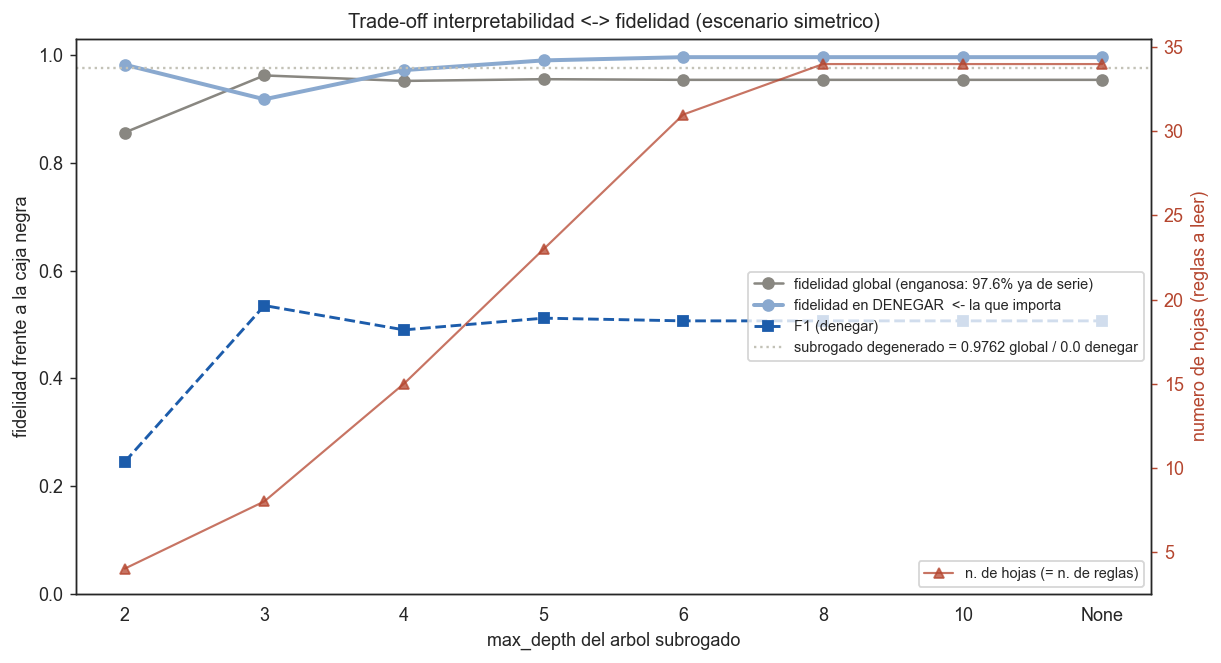

In [3]:
# FIGURA: la curva del trade-off. Dos ejes: fidelidad (izq) y numero de hojas (der).
# El eje de hojas es la medida real de INTERPRETABILIDAD: cada hoja es una regla que un
# humano tendria que leer. 8 reglas se leen; 400 no.
prof_x = [str(p) for p in barrido_c1["max_depth"]]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(prof_x, barrido_c1["fidelidad_global"], "o-", color=COLOR_MUTED, lw=1.4,
        label="fidelidad global (enganosa: 97.6% ya de serie)")
ax.plot(prof_x, barrido_c1["fid_denegar"], "o-", color=COLOR_ESC1, lw=2.2,
        label="fidelidad en DENEGAR  <- la que importa")
ax.plot(prof_x, barrido_c1["f1_denegar"], "s--", color=COLOR_GANADOR, lw=1.6,
        label="F1 (denegar)")
ax.axhline(met_deg["fidelidad_global"], color=COLOR_BASELINE, ls=":", lw=1.3,
           label=f"subrogado degenerado = {met_deg['fidelidad_global']:.4f} global / 0.0 denegar")
ax.set_xlabel("max_depth del arbol subrogado")
ax.set_ylabel("fidelidad frente a la caja negra")
ax.set_ylim(0, 1.03)
ax.set_title("Trade-off interpretabilidad <-> fidelidad (escenario simetrico)", fontsize=11)
ax.legend(fontsize=8, loc="center right")

# Eje derecho: numero de hojas = numero de reglas = coste de interpretabilidad.
ax2 = ax.twinx()
ax2.plot(prof_x, barrido_c1["n_hojas"], "^-", color=COLOR_ESC2, lw=1.2, alpha=0.75,
         label="n. de hojas (= n. de reglas)")
ax2.set_ylabel("numero de hojas (reglas a leer)", color=COLOR_ESC2)
ax2.tick_params(axis="y", colors=COLOR_ESC2)
ax2.grid(False)
ax2.legend(fontsize=8, loc="lower right")

guardar_figura(fig, "sub_05_fidelidad_vs_profundidad_coste1")

In [4]:
# --- Barrido 2: el efecto de class_weight sobre la CALIDAD de las reglas ---
# El barrido anterior revela un problema: con class_weight="balanced", el subrogado caza casi
# todos los denegados (recall/fid_denegar ~0.98) pero con una precision PESIMA (0.14-0.38), es
# decir, deniega a MUCHA mas gente que la caja negra. Sus reglas describirian un modelo mas
# severo que el real: mala explicacion. Contrastamos tres regimenes de peso.

def barrer_pesos(X, y_bb, profundidades, pesos):
    filas = []
    for peso_nombre, peso in pesos:
        for d in profundidades:
            arbol = DecisionTreeClassifier(
                max_depth=d, class_weight=peso, min_samples_leaf=50,
                random_state=RANDOM_STATE,
            )
            arbol.fit(X, y_bb)
            y_sub = arbol.predict(X)
            met = metricas_fidelidad(y_bb, y_sub)
            met["peso"] = peso_nombre
            met["max_depth"] = d
            met["n_hojas"] = int(arbol.get_n_leaves())
            met["tasa_deny_sub"] = float(y_sub.mean())   # cuanto deniega el ARBOL
            filas.append(met)
    cols = ["peso", "max_depth", "n_hojas", "tasa_deny_sub", "fidelidad_global",
            "fid_denegar", "prec_denegar", "f1_denegar"]
    return pd.DataFrame(filas)[cols]


PESOS = [("balanced", "balanced"), ("sin_peso", None), ("peso_5", {0: 1, 1: 5})]

barrido_pesos_c1 = barrer_pesos(X_test, y_bb_c1, [3, 4, 5, 6], PESOS)

print(f"La CAJA NEGRA deniega al {deny_c1 * 100:.2f}%. Un buen subrogado deberia denegar a una")
print("tasa PARECIDA (columna tasa_deny_sub), no al triple.")
print("=" * 96)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(barrido_pesos_c1.to_string(index=False))
print("=" * 96)
print(f"[objetivo] tasa_deny_sub ~ {deny_c1:.4f}   |   f1_denegar lo mas alto posible")

guardar_tabla(barrido_pesos_c1, "sub_05_barrido_pesos_coste1")

La CAJA NEGRA deniega al 2.38%. Un buen subrogado deberia denegar a una
tasa PARECIDA (columna tasa_deny_sub), no al triple.
    peso  max_depth  n_hojas  tasa_deny_sub  fidelidad_global  fid_denegar  prec_denegar  f1_denegar
balanced          3        8         0.0578            0.9621       0.9178        0.3776      0.5350
balanced          4       15         0.0705            0.9519       0.9719        0.3275      0.4899
balanced          5       23         0.0682            0.9551       0.9900        0.3450      0.5117
balanced          6       31         0.0697            0.9539       0.9960        0.3397      0.5066
sin_peso          3        8         0.0159            0.9880       0.5812        0.8709      0.6971
sin_peso          4       12         0.0131            0.9880       0.5230        0.9491      0.6744
sin_peso          5       16         0.0171            0.9887       0.6212        0.8635      0.7226
sin_peso          6       20         0.0171            0.9887      

'results/tables/sub_05_barrido_pesos_coste1.csv'

In [5]:
# 1) El "peso_5" no es magico: barremos el peso finamente para ver la frontera.
pesos_finos = [("sin_peso", None), ("peso_2", {0: 1, 1: 2}), ("peso_3", {0: 1, 1: 3}),
               ("peso_5", {0: 1, 1: 5}), ("peso_8", {0: 1, 1: 8}),
               ("peso_15", {0: 1, 1: 15}), ("balanced", "balanced")]
barrido_fino = barrer_pesos(X_test, y_bb_c1, [5], pesos_finos)
print("Peso de clase vs calidad del subrogado (max_depth=5 fijo)")
print(f"objetivo: tasa_deny_sub ~ {deny_c1:.4f}")
print("=" * 96)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(barrido_fino.to_string(index=False))
print("=" * 96)

Peso de clase vs calidad del subrogado (max_depth=5 fijo)
objetivo: tasa_deny_sub ~ 0.0238
    peso  max_depth  n_hojas  tasa_deny_sub  fidelidad_global  fid_denegar  prec_denegar  f1_denegar
sin_peso          5       16         0.0171            0.9887       0.6212        0.8635      0.7226
  peso_2          5       19         0.0277            0.9865       0.7996        0.6856      0.7382
  peso_3          5       23         0.0259            0.9879       0.7896        0.7256      0.7562
  peso_5          5       23         0.0329            0.9842       0.8597        0.6208      0.7210
  peso_8          5       23         0.0474            0.9737       0.9439        0.4734      0.6305
 peso_15          5       23         0.0534            0.9684       0.9599        0.4269      0.5910
balanced          5       23         0.0682            0.9551       0.9900        0.3450      0.5117


In [6]:
# 2) SOBREAJUSTE: hasta ahora entrenamos y evaluamos el subrogado en TEST (21000 filas).
#    Es lo estandar en subrogados (imitamos al modelo donde opera), pero hay que comprobar
#    que las reglas no estan memorizando: partimos test en 2 y medimos fidelidad OUT-OF-SAMPLE.
from sklearn.model_selection import train_test_split

Xa, Xb, ya, yb = train_test_split(X_test, y_bb_c1, test_size=0.5,
                                  stratify=y_bb_c1, random_state=RANDOM_STATE)
arb = DecisionTreeClassifier(max_depth=5, class_weight={0: 1, 1: 5},
                             min_samples_leaf=50, random_state=RANDOM_STATE)
arb.fit(Xa, ya)
met_in = metricas_fidelidad(ya, arb.predict(Xa))
met_out = metricas_fidelidad(yb, arb.predict(Xb))
print("Fidelidad del subrogado (peso_5, depth=5) dentro y fuera de muestra:")
print(f"  IN  (mitad de ajuste)   f1_denegar={met_in['f1_denegar']:.4f}  "
      f"fid_denegar={met_in['fid_denegar']:.4f}  global={met_in['fidelidad_global']:.4f}")
print(f"  OUT (mitad no vista)    f1_denegar={met_out['f1_denegar']:.4f}  "
      f"fid_denegar={met_out['fid_denegar']:.4f}  global={met_out['fidelidad_global']:.4f}")
print()
print("Si el gap IN-OUT es pequeno, las reglas GENERALIZAN: describen la logica de la caja")
print("negra, no memorizan casos concretos de test.")

Fidelidad del subrogado (peso_5, depth=5) dentro y fuera de muestra:
  IN  (mitad de ajuste)   f1_denegar=0.6737  fid_denegar=0.8880  global=0.9795
  OUT (mitad no vista)    f1_denegar=0.6404  fid_denegar=0.8795  global=0.9766

Si el gap IN-OUT es pequeno, las reglas GENERALIZAN: describen la logica de la caja
negra, no memorizan casos concretos de test.


**Hallazgo 2.1 (la fidelidad global es una metrica MENTIROSA aqui):** El resultado mas importante de
esta tabla no es cual es el mejor arbol, sino que **ningun arbol supera al subrogado degenerado en
fidelidad global**:

| subrogado | fidelidad global | fidelidad en DENEGAR |
|---|---|---|
| degenerado ("conceder siempre") | **0.9762** | **0.0000** |
| mejor arbol (`max_depth=3`) | 0.9621 | 0.9178 |

Leido solo por la columna de la izquierda, el veredicto seria demoledor: *el subrogado es PEOR que no
hacer nada*. Y es falso. El arbol de profundidad 3 captura al **92%** de los solicitantes que la caja
negra deniega; el degenerado, al **0%**. La fidelidad global no es que sea poco informativa: es
**activamente enganosa**, porque con solo un 2.38% de denegaciones el 97.6% de la muestra se acierta
sin hacer nada. Esto valida por completo el aviso que dejamos por adelantado en D-5.1, y es la razon
por la que este notebook nunca reporta la fidelidad global sin acompanarla.

**Sobre la forma de la curva.** La fidelidad en denegar NO crece de forma monotona con la
profundidad (0.982 a depth 2, baja a 0.918 a depth 3, sube a 0.996 a depth 6). No es una anomalia:
con `class_weight="balanced"` el arbol persigue la clase minoritaria de forma tan agresiva que el
recall se satura casi de inmediato, y lo que cambia entre profundidades es sobre todo **a costa de
cuanta precision** lo consigue. La precision lo delata: entre 0.14 y 0.38 en todas las
profundidades. Traducido: el arbol deniega a MUCHA mas gente que la caja negra.

**El arbol se satura solo.** A partir de `max_depth=8` la profundidad real deja de crecer (se queda
en 8) y las hojas se estabilizan en 34, aunque quitemos el limite (`max_depth=None`). Lo frena
`min_samples_leaf=50`, que exige que cada regla tenga al menos 50 casos de soporte. El hallazgo de
fondo: **la logica de la caja negra es aproximable con ~34 reglas de soporte razonable**. XGBoost usa
300 arboles, pero la frontera de decision que produce no es tan barroca como su tamano sugiere.

Este diagnostico obliga a revisar `class_weight="balanced"`: si el subrogado deniega al triple que el
modelo real, sus reglas describen un modelo mas severo que el que opera de hecho, y como explicacion
serian **falsas**. La celda siguiente barre el peso de clase para encontrar el punto de equilibrio.

**Hallazgo 2.2 (el peso de clase tiene un OPTIMO INTERIOR, y no es `balanced`):** Barriendo el peso
de la clase "denegar" con `max_depth=5` fijo, el F1 dibuja una curva con maximo claro:

| peso | tasa denegacion del arbol | fid. denegar (cobertura) | precision | F1 |
|---|---|---|---|---|
| sin peso | 0.0171 | 0.6212 | **0.8635** | 0.7226 |
| peso 2 | 0.0277 | 0.7996 | 0.6856 | 0.7382 |
| **peso 3** | **0.0259** | 0.7896 | 0.7256 | **0.7562** |
| peso 5 | 0.0329 | 0.8597 | 0.6208 | 0.7210 |
| peso 8 | 0.0474 | 0.9439 | 0.4734 | 0.6305 |
| `balanced` (~41) | 0.0682 | **0.9900** | 0.3450 | 0.5117 |

*(la caja negra deniega al **0.0238**; ese es el objetivo de la segunda columna)*

El trade-off es nitido y va en la direccion esperada: **a mas peso, mas cobertura y menos
precision**. Los dos extremos fallan por motivos OPUESTOS:

- **Sin reponderar** el arbol es *timido*: cuando deniega acierta casi siempre (precision 0.86) pero
  se deja fuera al **38%** de las denegaciones reales. Sus reglas serian ciertas pero INCOMPLETAS:
  explicarian solo dos tercios de los rechazos.
- **`balanced`** (que equivale a un peso de ~41, dado el desbalanceo 2.38/97.62) es *paranoico*:
  captura el 99% de las denegaciones, pero denegando al **6.8%** de la muestra -casi el triple que la
  caja negra- y con una precision de 0.35. De cada 3 personas a las que este arbol deniega, 2
  obtendrian el credito en realidad. Sus reglas describirian un modelo mas severo que el real: como
  explicacion, **mienten**.

**Eleccion: `peso = 3`.** Maximiza el F1 (0.7562) y ademas su tasa de denegacion (2.59%) es la que
mas se aproxima a la de la caja negra (2.38%), lo cual es un criterio de sanidad independiente del
F1: un buen imitador deniega a tanta gente como el imitado. Que el optimo sea interior -y no un
extremo- confirma que ni la opcion ingenua (no tocar nada) ni la opcion por defecto (`balanced`) eran
adecuadas. Esto **cierra D-5.1** en su parte de reponderacion.

**Eleccion: `max_depth = 5`.** El arbol se satura ahi (depth 5 y depth 6 dan metricas IDENTICAS con
`peso_5`), asi que no es una eleccion arbitraria: es el punto donde la curva se aplana. Da **23
hojas**, es decir, 23 reglas. Se conserva ademas un **subrogado de bolsillo** con `max_depth=3` (8
hojas, F1 0.676): pierde poca fidelidad y es el unico que un humano puede leer de un vistazo, asi que
sera el que usemos en la seccion 6 para responder a la pregunta del enunciado ("si un cliente pide
explicaciones, que informacion le damos?"). El operativo (23 reglas) audita; el comunicable (8
reglas) explica.

**Las reglas GENERALIZAN (no memorizan):** ajustando el subrogado sobre la mitad de test y midiendo
en la mitad no vista, el gap es despreciable:

| | F1 (denegar) | fidelidad denegar | fidelidad global |
|---|---|---|---|
| dentro de muestra | 0.6737 | 0.8880 | 0.9795 |
| **fuera de muestra** | **0.6404** | **0.8795** | **0.9766** |

Un gap de 0.033 en F1 y 0.009 en cobertura. El subrogado no esta memorizando casos concretos del
conjunto de test: esta capturando la **logica** de la caja negra, que es justo lo que un explicador
debe hacer. (Los valores absolutos son algo menores que en la tabla principal porque este arbol se
ajusta con la mitad de los datos, 10500 filas en vez de 21000; lo relevante es el GAP, no el nivel.)

**Nota metodologica.** Ajustar y evaluar el subrogado sobre el mismo conjunto (test) es el patron
estandar en modelos subrogados, y no constituye fuga: no estamos seleccionando hiperparametros del
modelo principal -que esta cerrado desde `03`/`04`- sino DESCRIBIENDO su comportamiento sobre la
muestra donde opera. Aun asi, la comprobacion in/out de arriba deja documentado que las reglas
resisten fuera de muestra.

## 3. Ajuste del arbol subrogado para el escenario coste10

Analogo a la seccion 2, pero usando `modelo_coste10` y entrenando un arbol subrogado propio e
independiente para este escenario de coste.

In [ ]:
# TODO: 3. Ajuste del arbol subrogado para el escenario coste10

## 4. Extraccion de reglas legibles (ver utilidades referenciadas en docs/teoria/subrogados.md)

Extraer reglas if/then de cada arbol subrogado (soporte y pureza por hoja), guardando el
resultado en `results/tables/reglas_subrogado_coste1.md` y
`results/tables/reglas_subrogado_coste10.md`, junto con las figuras de los arboles en
`results/figures/arbol_subrogado_coste1.png` y `results/figures/arbol_subrogado_coste10.png`.

In [ ]:
# TODO: 4. Extraccion de reglas legibles (ver utilidades referenciadas en docs/teoria/subrogados.md)

## 5. Medicion de fidelidad del subrogado frente al modelo original

Calcular la fidelidad de cada arbol subrogado frente a las predicciones del modelo caja negra
correspondiente (no frente al target real), consolidando los resultados en una tabla
comparativa entre los dos escenarios de coste.

In [ ]:
# TODO: 5. Medicion de fidelidad del subrogado frente al modelo original

## 6. Interpretacion de las reglas obtenidas

Lectura cualitativa de las reglas extraidas en la seccion 4, contrastando que variables y
umbrales aparecen en cada escenario de coste y si la fidelidad es homogenea o varia entre
subgrupos de casos.

In [ ]:
# TODO: 6. Interpretacion de las reglas obtenidas

## 7. Conclusiones

Resumen de resultados de la auditoria con modelo subrogado (fidelidad alcanzada por escenario,
reglas mas relevantes) de cara a `99_ENTREGA.ipynb`.

In [ ]:
# TODO: 7. Conclusiones